In [1]:
import pandas as pd
import numpy as np

from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams["figure.figsize"] = (10,5)


In [4]:
df.duplicated().sum()
df = df.drop_duplicates()

In [6]:
df["Rating"] = (
             df["Rating"].astype(str)
             .astype(str)
             .str.lower()
             .str.strip()
)

In [8]:
(df[["reaction_count", "comment_count", "share_count"]] < 0).sum()

reaction_count    0
comment_count     0
share_count       0
dtype: int64

In [11]:
for col in ["reaction_count", "comment_count", "share_count"]:
    df = df[df[col]>=0]

In [13]:
df.head()

,account_id,post_id,Category,Page,Post URL,Date Published,Post Type,Rating,Debate,share_count,reaction_count,comment_count
1,184096565021911,1035269309904628,mainstream,ABC News Politics,https://www.facebook.com/ABCNewsPolitics/posts...,2016-09-19,link,mostly true,NaN,1.0,33.0,34.0
2,184096565021911,1035305953234297,mainstream,ABC News Politics,https://www.facebook.com/ABCNewsPolitics/posts...,2016-09-19,link,mostly true,NaN,34.0,63.0,27.0
3,184096565021911,1035322636565962,mainstream,ABC News Politics,https://www.facebook.com/ABCNewsPolitics/posts...,2016-09-19,link,mostly true,NaN,35.0,170.0,86.0
4,184096565021911,1035352946562931,mainstream,ABC News Politics,https://www.facebook.com/ABCNewsPolitics/posts...,2016-09-19,video,mostly true,NaN,568.0,3188.0,2815.0
5,184096565021911,1035366579894901,mainstream,ABC News Politics,https://www.facebook.com/ABCNewsPolitics/posts...,2016-09-19,link,mostly true,NaN,23.0,28.0,21.0


In [14]:
df["total_engagement"] = (
    df["reaction_count"] +
    df["comment_count"] +
    df["share_count"]
)


In [15]:
df["total_engagement"].describe()


count    2.212000e+03
mean     9.975195e+03
std      5.063570e+04
min      9.000000e+00
25%      2.567500e+02
50%      8.810000e+02
75%      3.855500e+03
max      1.704500e+06
Name: total_engagement, dtype: float64

In [16]:
df["total_engagement"] = (
    df["reaction_count"] +
    df["comment_count"] +
    df["share_count"]
)

df["total_engagement"].describe()


count    2.212000e+03
mean     9.975195e+03
std      5.063570e+04
min      9.000000e+00
25%      2.567500e+02
50%      8.810000e+02
75%      3.855500e+03
max      1.704500e+06
Name: total_engagement, dtype: float64

In [17]:
Q1 = df["total_engagement"].quantile(0.25)
Q3 = df["total_engagement"].quantile(0.75)

IQR = Q3 - Q1


In [19]:
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df = df[
    (df["total_engagement"] >= lower_bound) &
    (df["total_engagement"] <= upper_bound)
]


In [21]:
df["Date Published"] = pd.to_datetime(df["Date Published"], errors="coerce")


/var/folders/md/2nrzbd411dq9zq60tz3q1p5r0000gn/T/ipykernel_31797/2583511892.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Date Published"] = pd.to_datetime(df["Date Published"], errors="coerce")


In [22]:
df = df.dropna(subset=["Date Published"])


In [23]:
rating_map = {
    "mostly true": "true",
    "half true": "mixed",
    "mostly false": "false",
    "pants on fire": "false"
}


In [24]:
df["rating_grouped"] = df["Rating"].replace(rating_map)


RE-CREATE A/B GROUP AFTER CLEANING


In [25]:
human_ratings = ["true", "no factual content"]


In [26]:
df["ab_group"] = np.where(
    df["rating_grouped"].isin(human_ratings),
    "Human_Content",
    "AI_Like_Content"
)


In [27]:
df.isnull().sum()
df["ab_group"].value_counts()


ab_group
Human_Content      1609
AI_Like_Content     254
Name: count, dtype: int64

In [28]:
df["total_engagement"] = (
    df["reaction_count"] +
    df["comment_count"] +
    df["share_count"]
)


In [30]:
df["reaction_ratio"] = df["reaction_count"] / (df["total_engagement"] + 1)
df["comment_ratio"]  = df["comment_count"] / (df["total_engagement"] + 1)
df["share_ratio"]    = df["share_count"] / (df["total_engagement"] + 1)


In [31]:
df["virality_score"] = df["share_count"] / (df["reaction_count"] + 1)


In [32]:
df["discussion_intensity"] = df["comment_count"] / (df["reaction_count"] + 1)


In [33]:
df["engagement_normalized"] = (
    df["total_engagement"] - df["total_engagement"].min()
) / (
    df["total_engagement"].max() - df["total_engagement"].min()
)


In [34]:
df["log_engagement"] = np.log1p(df["total_engagement"])


In [35]:
df["is_high_credibility"] = np.where(
    df["rating_grouped"].isin(["true", "no factual content"]),
    1,
    0
)


In [36]:
df["credibility_weighted_engagement"] = (
    df["total_engagement"] * df["is_high_credibility"]
)


In [38]:
df["year"]  = df["Date Published"].dt.year
df["month"] = df["Date Published"].dt.month
df["day"]   = df["Date Published"].dt.day
df["weekday"] = df["Date Published"].dt.day_name()


In [40]:
df["engagement_velocity"] = df["total_engagement"] / (
    (df["Date Published"].max() - df["Date Published"]).dt.days + 1
)


In [41]:
df["engagement_bucket"] = pd.qcut(
    df["total_engagement"],
    q=3,
    labels=["Low", "Medium", "High"]
)


In [42]:
df["content_risk"] = np.where(
    (df["is_high_credibility"] == 0) & (df["virality_score"] > 1),
    "High Risk",
    "Normal"
)


In [43]:
df.head()


,account_id,post_id,Category,Page,Post URL,Date Published,Post Type,Rating,Debate,share_count,...,log_engagement,is_high_credibility,credibility_weighted_engagement,year,month,day,weekday,engagement_velocity,engagement_bucket,content_risk
1,184096565021911,1035269309904628,mainstream,ABC News Politics,https://www.facebook.com/ABCNewsPolitics/posts...,2016-09-19,link,mostly true,NaN,1.0,...,4.234107,1,68.0,2016,9,19,Monday,7.555556,Low,Normal
2,184096565021911,1035305953234297,mainstream,ABC News Politics,https://www.facebook.com/ABCNewsPolitics/posts...,2016-09-19,link,mostly true,NaN,34.0,...,4.828314,1,124.0,2016,9,19,Monday,13.777778,Low,Normal
3,184096565021911,1035322636565962,mainstream,ABC News Politics,https://www.facebook.com/ABCNewsPolitics/posts...,2016-09-19,link,mostly true,NaN,35.0,...,5.676754,1,291.0,2016,9,19,Monday,32.333333,Medium,Normal
4,184096565021911,1035352946562931,mainstream,ABC News Politics,https://www.facebook.com/ABCNewsPolitics/posts...,2016-09-19,video,mostly true,NaN,568.0,...,8.790573,1,6571.0,2016,9,19,Monday,730.111111,High,Normal
5,184096565021911,1035366579894901,mainstream,ABC News Politics,https://www.facebook.com/ABCNewsPolitics/posts...,2016-09-19,link,mostly true,NaN,23.0,...,4.290459,1,72.0,2016,9,19,Monday,8.000000,Low,Normal


In [44]:
df["ab_group_basic"] = np.where(
    df["rating_grouped"].isin(["true", "no factual content"]),
    "Human_Content",
    "AI_Like_Content"
)


In [47]:
df_strict = df[df["rating_grouped"].isin(["true", "false"])]

df_strict["ab_group_strict"] = np.where(df_strict["rating_grouped"] == "true",
    "Human_Content",
    "AI_Like_Content"
)


/var/folders/md/2nrzbd411dq9zq60tz3q1p5r0000gn/T/ipykernel_31797/2793646869.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_strict["ab_group_strict"] = np.where(df_strict["rating_grouped"] == "true",


In [48]:
quality_map = {
    "true": 3,
    "no factual content": 2,
    "mixed": 1,
    "false": 0
}


In [49]:
df["quality_score"] = df["rating_grouped"].map(quality_map)


In [50]:
df["ab_group_quality"] = np.where(
    df["quality_score"] >= 2,
    "High_Quality",
    "Low_Quality"
)


In [51]:
df["engagement_bucket"] = pd.qcut(
    df["total_engagement"],
    q=3,
    labels=["Low", "Medium", "High"]
)


In [52]:
df["ab_group_controlled"] = (
    df["ab_group_basic"] + "_" + df["engagement_bucket"].astype(str)
)


In [53]:
df.head()


,account_id,post_id,Category,Page,Post URL,Date Published,Post Type,Rating,Debate,share_count,...,month,day,weekday,engagement_velocity,engagement_bucket,content_risk,ab_group_basic,quality_score,ab_group_quality,ab_group_controlled
1,184096565021911,1035269309904628,mainstream,ABC News Politics,https://www.facebook.com/ABCNewsPolitics/posts...,2016-09-19,link,mostly true,NaN,1.0,...,9,19,Monday,7.555556,Low,Normal,Human_Content,3.0,High_Quality,Human_Content_Low
2,184096565021911,1035305953234297,mainstream,ABC News Politics,https://www.facebook.com/ABCNewsPolitics/posts...,2016-09-19,link,mostly true,NaN,34.0,...,9,19,Monday,13.777778,Low,Normal,Human_Content,3.0,High_Quality,Human_Content_Low
3,184096565021911,1035322636565962,mainstream,ABC News Politics,https://www.facebook.com/ABCNewsPolitics/posts...,2016-09-19,link,mostly true,NaN,35.0,...,9,19,Monday,32.333333,Medium,Normal,Human_Content,3.0,High_Quality,Human_Content_Medium
4,184096565021911,1035352946562931,mainstream,ABC News Politics,https://www.facebook.com/ABCNewsPolitics/posts...,2016-09-19,video,mostly true,NaN,568.0,...,9,19,Monday,730.111111,High,Normal,Human_Content,3.0,High_Quality,Human_Content_High
5,184096565021911,1035366579894901,mainstream,ABC News Politics,https://www.facebook.com/ABCNewsPolitics/posts...,2016-09-19,link,mostly true,NaN,23.0,...,9,19,Monday,8.000000,Low,Normal,Human_Content,3.0,High_Quality,Human_Content_Low


In [55]:
median_date = df["Date Published"].median()


In [57]:
df["ab_group_time"] = np.where(
    df["Date Published"] <= median_date,
    "Pre_Period",
    "Post_Period"
)


In [59]:

df["ab_group_risk"] = np.where(
    (df["is_high_credibility"] == 0) & (df["virality_score"] > 1),
    "High_Risk_Content",
    "Low_Risk_Content"
)


In [60]:
df.groupby("ab_group_basic")["total_engagement"].mean()
df.groupby("ab_group_quality")["total_engagement"].mean()
df.groupby("ab_group_risk")["total_engagement"].mean()


ab_group_risk
High_Risk_Content    3037.500000
Low_Risk_Content     1359.489362
Name: total_engagement, dtype: float64

In [61]:
from scipy.stats import ttest_ind, mannwhitneyu


In [62]:
def run_ab_test(df, group_col, metric):
    """
    Runs T-test and Mann-Whitney U test
    for a given A/B group column and metric
    """
    groups = df[group_col].dropna().unique()
    
    if len(groups) != 2:
        print(f"{group_col}: Not a valid A/B split")
        return
    
    group_a = df[df[group_col] == groups[0]][metric]
    group_b = df[df[group_col] == groups[1]][metric]
    
    t_stat, t_p = ttest_ind(group_a, group_b, equal_var=False)
    u_stat, u_p = mannwhitneyu(group_a, group_b, alternative="two-sided")
    
    print(f"\nA/B Group: {group_col}")
    print(f"Metric: {metric}")
    print(f"Groups: {groups[0]} vs {groups[1]}")
    print(f"T-test p-value: {t_p:.4f}")
    print(f"Mann-Whitney p-value: {u_p:.4f}")


In [63]:
#Are engagement differences real or luck?
run_ab_test(df, "ab_group_basic", "total_engagement")



A/B Group: ab_group_basic
Metric: total_engagement
Groups: Human_Content vs AI_Like_Content
T-test p-value: 0.0000
Mann-Whitney p-value: 0.0000


In [64]:
run_ab_test(df_strict, "ab_group_strict", "total_engagement")



A/B Group: ab_group_strict
Metric: total_engagement
Groups: Human_Content vs AI_Like_Content
T-test p-value: 0.0000
Mann-Whitney p-value: 0.0000


In [65]:
run_ab_test(df, "ab_group_quality", "total_engagement")



A/B Group: ab_group_quality
Metric: total_engagement
Groups: High_Quality vs Low_Quality
T-test p-value: 0.0000
Mann-Whitney p-value: 0.0000


In [66]:
run_ab_test(df, "ab_group_risk", "total_engagement")



A/B Group: ab_group_risk
Metric: total_engagement
Groups: Low_Risk_Content vs High_Risk_Content
T-test p-value: 0.0007
Mann-Whitney p-value: 0.0000


In [67]:
#METRIC ROBUSTNESS
run_ab_test(df, "ab_group_basic", "virality_score")
run_ab_test(df, "ab_group_basic", "discussion_intensity")



A/B Group: ab_group_basic
Metric: virality_score
Groups: Human_Content vs AI_Like_Content
T-test p-value: 0.0000
Mann-Whitney p-value: 0.0000

A/B Group: ab_group_basic
Metric: discussion_intensity
Groups: Human_Content vs AI_Like_Content
T-test p-value: 0.0000
Mann-Whitney p-value: 0.0000


In [68]:
alpha = 0.05


In [69]:
summary = []

tests = [
    ("ab_group_basic", df),
    ("ab_group_quality", df),
    ("ab_group_risk", df),
]

for group_col, data in tests:
    groups = data[group_col].dropna().unique()
    if len(groups) == 2:
        a = data[data[group_col] == groups[0]]["total_engagement"]
        b = data[data[group_col] == groups[1]]["total_engagement"]
        _, p = ttest_ind(a, b, equal_var=False)
        summary.append([group_col, p])

pd.DataFrame(summary, columns=["A/B Definition", "T-test p-value"])


,A/B Definition,T-test p-value
0,ab_group_basic,6.332942e-12
1,ab_group_quality,6.332942e-12
2,ab_group_risk,7.113620e-04


In [70]:
# Shape of the dataset
df.shape

# Data types and non-null counts
df.info()

# Missing values per column
df.isnull().sum()

# Duplicate rows
df.duplicated().sum()


<class 'pandas.core.frame.DataFrame'>
Index: 1863 entries, 1 to 2278
Data columns (total 37 columns):
 #   Column                           Non-Null Count  Dtype         
---  ------                           --------------  -----         
 0   account_id                       1863 non-null   int64         
 1   post_id                          1863 non-null   int64         
 2   Category                         1863 non-null   object        
 3   Page                             1863 non-null   object        
 4   Post URL                         1863 non-null   object        
 5   Date Published                   1863 non-null   datetime64[ns]
 6   Post Type                        1863 non-null   object        
 7   Rating                           1863 non-null   object        
 8   Debate                           227 non-null    object        
 9   share_count                      1863 non-null   float64       
 10  reaction_count                   1863 non-null   float64       
 

np.int64(0)

In [71]:
# Descriptive statistics
df["total_engagement"].describe()

# Skewness (positive = right skewed)
df["total_engagement"].skew()


np.float64(2.1014660959449083)

In [72]:
# High-percentile thresholds
df["total_engagement"].quantile([0.90, 0.95, 0.99])

# Count of extreme viral posts
(df["total_engagement"] > df["total_engagement"].quantile(0.99)).sum()


np.int64(19)

In [73]:
df.groupby("ab_group_basic")["total_engagement"].agg([
    "count",
    "mean",
    "median",
    "std",
    "min",
    "max"
])


,count,mean,median,std,min,max
ab_group_basic,,,,,,
AI_Like_Content,254,2334.622047,1350.0,2344.364793,45.0,9106.0
Human_Content,1609,1236.839652,515.0,1735.998682,9.0,9231.0


In [74]:
df.groupby("ab_group_basic")[[
    "reaction_ratio",
    "comment_ratio",
    "share_ratio"
]].mean()


,reaction_ratio,comment_ratio,share_ratio
ab_group_basic,,,
AI_Like_Content,0.613058,0.101655,0.283214
Human_Content,0.637585,0.216298,0.141114


In [75]:
df.groupby("ab_group_risk")["virality_score"].agg([
    "count",
    "mean",
    "median",
    "max"
])


,count,mean,median,max
ab_group_risk,,,,
High_Risk_Content,30,1.451613,1.362197,2.610902
Low_Risk_Content,1833,0.263086,0.182432,2.133333


In [76]:
df.groupby("quality_score")["total_engagement"].agg([
    "count",
    "mean",
    "median"
]).sort_index(ascending=False)


,count,mean,median
quality_score,,,
3.0,1477,1231.171293,511.0
2.0,132,1300.265152,703.0
0.0,72,2746.944444,1708.0


In [81]:
# Monthly trend
monthly_engagement = (
    df.resample("M", on="Date Published")["total_engagement"]
    .mean()
)

monthly_engagement


/var/folders/md/2nrzbd411dq9zq60tz3q1p5r0000gn/T/ipykernel_31797/2944597949.py:3: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df.resample("M", on="Date Published")["total_engagement"]


Date Published
2016-09-30    1386.510467
Freq: ME, Name: total_engagement, dtype: float64

In [79]:
df.head()

,account_id,post_id,Category,Page,Post URL,Date Published,Post Type,Rating,Debate,share_count,...,weekday,engagement_velocity,engagement_bucket,content_risk,ab_group_basic,quality_score,ab_group_quality,ab_group_controlled,ab_group_time,ab_group_risk
1,184096565021911,1035269309904628,mainstream,ABC News Politics,https://www.facebook.com/ABCNewsPolitics/posts...,2016-09-19,link,mostly true,NaN,1.0,...,Monday,7.555556,Low,Normal,Human_Content,3.0,High_Quality,Human_Content_Low,Pre_Period,Low_Risk_Content
2,184096565021911,1035305953234297,mainstream,ABC News Politics,https://www.facebook.com/ABCNewsPolitics/posts...,2016-09-19,link,mostly true,NaN,34.0,...,Monday,13.777778,Low,Normal,Human_Content,3.0,High_Quality,Human_Content_Low,Pre_Period,Low_Risk_Content
3,184096565021911,1035322636565962,mainstream,ABC News Politics,https://www.facebook.com/ABCNewsPolitics/posts...,2016-09-19,link,mostly true,NaN,35.0,...,Monday,32.333333,Medium,Normal,Human_Content,3.0,High_Quality,Human_Content_Medium,Pre_Period,Low_Risk_Content
4,184096565021911,1035352946562931,mainstream,ABC News Politics,https://www.facebook.com/ABCNewsPolitics/posts...,2016-09-19,video,mostly true,NaN,568.0,...,Monday,730.111111,High,Normal,Human_Content,3.0,High_Quality,Human_Content_High,Pre_Period,Low_Risk_Content
5,184096565021911,1035366579894901,mainstream,ABC News Politics,https://www.facebook.com/ABCNewsPolitics/posts...,2016-09-19,link,mostly true,NaN,23.0,...,Monday,8.000000,Low,Normal,Human_Content,3.0,High_Quality,Human_Content_Low,Pre_Period,Low_Risk_Content


In [80]:
df


,account_id,post_id,Category,Page,Post URL,Date Published,Post Type,Rating,Debate,share_count,...,weekday,engagement_velocity,engagement_bucket,content_risk,ab_group_basic,quality_score,ab_group_quality,ab_group_controlled,ab_group_time,ab_group_risk
1,184096565021911,1035269309904628,mainstream,ABC News Politics,https://www.facebook.com/ABCNewsPolitics/posts...,2016-09-19,link,mostly true,NaN,1.0,...,Monday,7.555556,Low,Normal,Human_Content,3.0,High_Quality,Human_Content_Low,Pre_Period,Low_Risk_Content
2,184096565021911,1035305953234297,mainstream,ABC News Politics,https://www.facebook.com/ABCNewsPolitics/posts...,2016-09-19,link,mostly true,NaN,34.0,...,Monday,13.777778,Low,Normal,Human_Content,3.0,High_Quality,Human_Content_Low,Pre_Period,Low_Risk_Content
3,184096565021911,1035322636565962,mainstream,ABC News Politics,https://www.facebook.com/ABCNewsPolitics/posts...,2016-09-19,link,mostly true,NaN,35.0,...,Monday,32.333333,Medium,Normal,Human_Content,3.0,High_Quality,Human_Content_Medium,Pre_Period,Low_Risk_Content
4,184096565021911,1035352946562931,mainstream,ABC News Politics,https://www.facebook.com/ABCNewsPolitics/posts...,2016-09-19,video,mostly true,NaN,568.0,...,Monday,730.111111,High,Normal,Human_Content,3.0,High_Quality,Human_Content_High,Pre_Period,Low_Risk_Content
5,184096565021911,1035366579894901,mainstream,ABC News Politics,https://www.facebook.com/ABCNewsPolitics/posts...,2016-09-19,link,mostly true,NaN,23.0,...,Monday,8.000000,Low,Normal,Human_Content,3.0,High_Quality,Human_Content_Low,Pre_Period,Low_Risk_Content
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2265,114517875225866,1471858869491753,left,The Other 98%,https://www.facebook.com/TheOther98/posts/1471...,2016-09-27,link,mostly true,NaN,1054.0,...,Tuesday,5883.000000,High,Normal,Human_Content,3.0,High_Quality,Human_Content_High,Post_Period,Low_Risk_Content
2267,114517875225866,1472006522810321,left,The Other 98%,https://www.facebook.com/TheOther98/posts/1472...,2016-09-27,link,mixture of true and false,yes,516.0,...,Tuesday,3247.000000,High,Normal,AI_Like_Content,NaN,Low_Quality,AI_Like_Content_High,Post_Period,Low_Risk_Content
2272,114517875225866,1472332029444437,left,The Other 98%,https://www.facebook.com/TheOther98/posts/1472...,2016-09-27,photo,mostly true,yes,506.0,...,Tuesday,5370.000000,High,Normal,Human_Content,3.0,High_Quality,Human_Content_High,Post_Period,Low_Risk_Content
2273,114517875225866,1472332886111018,left,The Other 98%,https://www.facebook.com/TheOther98/posts/1472...,2016-09-27,video,no factual content,yes,3387.0,...,Tuesday,8899.000000,High,Normal,Human_Content,2.0,High_Quality,Human_Content_High,Post_Period,Low_Risk_Content


In [82]:
df.groupby("ab_group_basic")["engagement_velocity"].agg([
    "mean",
    "median",
    "max"
])


,mean,median,max
ab_group_basic,,,
AI_Like_Content,768.995190,241.275000,9106.0
Human_Content,471.616051,121.444444,8969.0


In [83]:
df["engagement_bucket"].value_counts()

df.groupby(["engagement_bucket", "ab_group_basic"]).size()


/var/folders/md/2nrzbd411dq9zq60tz3q1p5r0000gn/T/ipykernel_31797/3204380483.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(["engagement_bucket", "ab_group_basic"]).size()


engagement_bucket  ab_group_basic 
Low                AI_Like_Content     46
                   Human_Content      575
Medium             AI_Like_Content     66
                   Human_Content      555
High               AI_Like_Content    142
                   Human_Content      479
dtype: int64

In [84]:
df[[
    "reaction_count",
    "comment_count",
    "share_count",
    "total_engagement",
    "virality_score",
    "discussion_intensity"
]].corr()


,reaction_count,comment_count,share_count,total_engagement,virality_score,discussion_intensity
reaction_count,1.000000,0.442162,0.703095,0.963616,0.096052,-0.317597
comment_count,0.442162,1.000000,0.348699,0.568179,0.025793,0.270271
share_count,0.703095,0.348699,1.000000,0.837004,0.548958,-0.255471
total_engagement,0.963616,0.568179,0.837004,1.000000,0.235849,-0.249107
virality_score,0.096052,0.025793,0.548958,0.235849,1.000000,-0.171622
discussion_intensity,-0.317597,0.270271,-0.255471,-0.249107,-0.171622,1.000000


In [85]:
df["ab_group_basic"].value_counts(normalize=True)


ab_group_basic
Human_Content      0.863661
AI_Like_Content    0.136339
Name: proportion, dtype: float64

In [86]:
df.groupby("ab_group_basic")["quality_score"].mean()


ab_group_basic
AI_Like_Content    0.000000
Human_Content      2.917961
Name: quality_score, dtype: float64

In [87]:
#Is the data ready for hypothesis testing?

df.head()
df.describe(include="all")

,account_id,post_id,Category,Page,Post URL,Date Published,Post Type,Rating,Debate,share_count,...,weekday,engagement_velocity,engagement_bucket,content_risk,ab_group_basic,quality_score,ab_group_quality,ab_group_controlled,ab_group_time,ab_group_risk
count,1.863000e+03,1.863000e+03,1863,1863,1863,1863,1863,1863,227,1863.000000,...,1863,1863.000000,1863,1863,1863,1681.000000,1863,1863,1863,1863
unique,NaN,NaN,3,9,1863,NaN,4,4,1,NaN,...,5,NaN,3,2,2,NaN,2,6,2,2
top,NaN,NaN,mainstream,Politico,https://www.facebook.com/ABCNewsPolitics/posts...,NaN,link,mostly true,yes,NaN,...,Monday,NaN,Low,Normal,Human_Content,NaN,High_Quality,Human_Content_Low,Pre_Period,Low_Risk_Content
freq,NaN,NaN,1106,527,1,NaN,1585,1477,227,NaN,...,579,NaN,621,1833,1609,NaN,1609,575,1022,1833
mean,1.684092e+14,3.706355e+15,NaN,NaN,NaN,2016-09-22 17:49:45.507246336,NaN,NaN,NaN,290.050456,...,NaN,512.160496,NaN,NaN,NaN,2.792980,NaN,NaN,NaN,NaN
min,6.231759e+10,5.510967e+14,NaN,NaN,NaN,2016-09-19 00:00:00,NaN,NaN,NaN,1.000000,...,NaN,1.285714,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,NaN
25%,6.231759e+10,1.246596e+15,NaN,NaN,NaN,2016-09-20 00:00:00,NaN,NaN,NaN,19.000000,...,NaN,41.533333,NaN,NaN,NaN,3.000000,NaN,NaN,NaN,NaN
50%,1.464230e+14,1.291428e+15,NaN,NaN,NaN,2016-09-22 00:00:00,NaN,NaN,NaN,63.000000,...,NaN,136.000000,NaN,NaN,NaN,3.000000,NaN,NaN,NaN,NaN
75%,2.193673e+14,1.015384e+16,NaN,NaN,NaN,2016-09-26 00:00:00,NaN,NaN,NaN,264.000000,...,NaN,473.200000,NaN,NaN,NaN,3.000000,NaN,NaN,NaN,NaN
max,4.401065e+14,1.015386e+16,NaN,NaN,NaN,2016-09-27 00:00:00,NaN,NaN,NaN,5870.000000,...,NaN,9106.000000,NaN,NaN,NaN,3.000000,NaN,NaN,NaN,NaN


In [88]:
group_a = df[df["ab_group_basic"] == "Human_Content"]["total_engagement"]
group_b = df[df["ab_group_basic"] == "AI_Like_Content"]["total_engagement"]


In [89]:
group_a.describe(), group_b.describe()


(count    1609.000000
 mean     1236.839652
 std      1735.998682
 min         9.000000
 25%       172.000000
 50%       515.000000
 75%      1476.000000
 max      9231.000000
 Name: total_engagement, dtype: float64,
 count     254.000000
 mean     2334.622047
 std      2344.364793
 min        45.000000
 25%       475.500000
 50%      1350.000000
 75%      3840.500000
 max      9106.000000
 Name: total_engagement, dtype: float64)

In [90]:
#RUN THE T-TEST
t_stat, p_value_ttest = ttest_ind(
    group_a,
    group_b,
    equal_var=False
)


In [92]:
alpha = 0.05

if p_value_ttest < alpha:
    ttest_result = "Reject H₀ (Significant)"
else:
    ttest_result = "Fail to Reject H₀"

if p_value_mwu < alpha:
    mwu_result = "Reject H₀ (Significant)"
else:
    mwu_result = "Fail to Reject H₀"

ttest_result, mwu_result


('Reject H₀ (Significant)', 'Reject H₀ (Significant)')

In [94]:
import numpy as np

def cohens_d(a, b):
    return (a.mean() - b.mean()) / np.sqrt(
        (a.var() + b.var()) / 2
    )

effect_size = cohens_d(group_a, group_b)
effect_size


np.float64(-0.5321979197382163)

In [95]:
results = pd.DataFrame({
    "Test": ["T-Test", "Mann-Whitney U"],
    "P-Value": [p_value_ttest, p_value_mwu],
    "Decision": [ttest_result, mwu_result]
})

results


,Test,P-Value,Decision
0,T-Test,6.332942e-12,Reject H₀ (Significant)
1,Mann-Whitney U,1.264769e-18,Reject H₀ (Significant)


In [96]:
group_a = df[df["ab_group_basic"] == "Human_Content"]["comment_ratio"]
group_b = df[df["ab_group_basic"] == "AI_Like_Content"]["comment_ratio"]

from scipy.stats import mannwhitneyu
u_stat, p_comment = mannwhitneyu(group_a, group_b)

p_comment


np.float64(1.7467914174263672e-35)

In [97]:
group_a = df[df["ab_group_basic"] == "Human_Content"]["virality_score"]
group_b = df[df["ab_group_basic"] == "AI_Like_Content"]["virality_score"]

u_stat, p_virality = mannwhitneyu(group_a, group_b)

p_virality


np.float64(1.1339013007158287e-49)

In [98]:
group_a = df[df["ab_group_basic"] == "Human_Content"]["discussion_intensity"]
group_b = df[df["ab_group_basic"] == "AI_Like_Content"]["discussion_intensity"]

u_stat, p_discussion = mannwhitneyu(group_a, group_b)

p_discussion


np.float64(2.59613944721972e-25)

In [100]:
risk = df[df["content_risk"] == "High Risk"]["total_engagement"]
normal = df[df["content_risk"] == "Normal"]["total_engagement"]

u_stat, p_risk = mannwhitneyu(risk, normal)

p_risk


np.float64(1.2999474476190942e-05)

/var/folders/md/2nrzbd411dq9zq60tz3q1p5r0000gn/T/ipykernel_31797/3052815954.py:5: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(


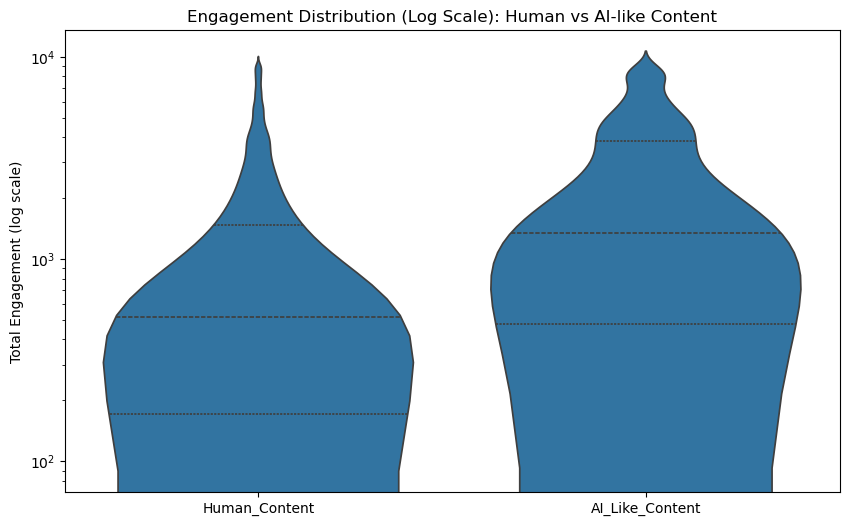

In [102]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.violinplot(
    data=df,
    x="ab_group_basic",
    y="total_engagement",
    inner="quartile",
    scale="width"
)
plt.yscale("log")
plt.title("Engagement Distribution (Log Scale): Human vs AI-like Content")
plt.xlabel("")
plt.ylabel("Total Engagement (log scale)")
plt.show()


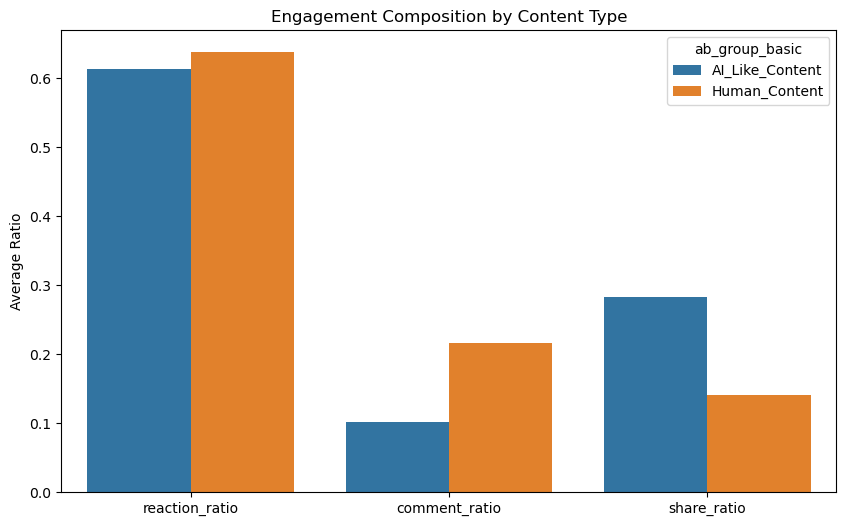

In [103]:
composition = df.groupby("ab_group_basic")[[
    "reaction_ratio", "comment_ratio", "share_ratio"
]].mean().reset_index()

composition_melted = composition.melt(
    id_vars="ab_group_basic",
    var_name="Engagement Type",
    value_name="Ratio"
)

plt.figure(figsize=(10,6))
sns.barplot(
    data=composition_melted,
    x="Engagement Type",
    y="Ratio",
    hue="ab_group_basic"
)
plt.title("Engagement Composition by Content Type")
plt.ylabel("Average Ratio")
plt.xlabel("")
plt.show()


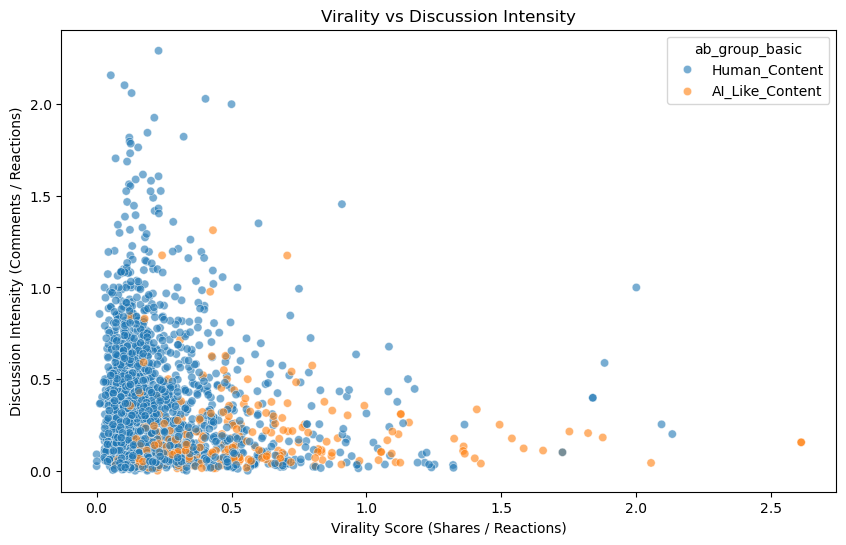

In [104]:
plt.figure(figsize=(10,6))
sns.scatterplot(
    data=df,
    x="virality_score",
    y="discussion_intensity",
    hue="ab_group_basic",
    alpha=0.6
)
plt.title("Virality vs Discussion Intensity")
plt.xlabel("Virality Score (Shares / Reactions)")
plt.ylabel("Discussion Intensity (Comments / Reactions)")
plt.show()


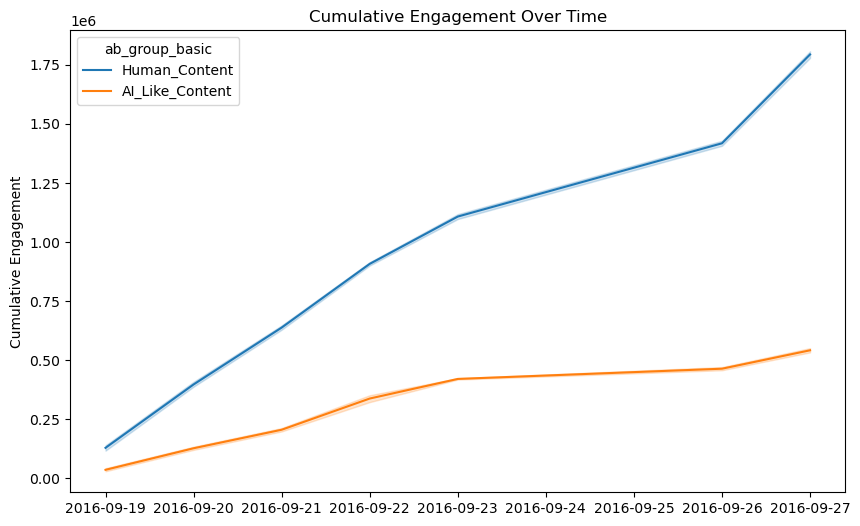

In [107]:
df_sorted = df.sort_values("Date Published")

df_sorted["cum_engagement"] = (
    df_sorted.groupby("ab_group_basic")["total_engagement"]
    .cumsum()
)

plt.figure(figsize=(10,6))
sns.lineplot(
    data=df_sorted,
    x="Date Published",
    y="cum_engagement",
    hue="ab_group_basic"
)
plt.title("Cumulative Engagement Over Time")
plt.ylabel("Cumulative Engagement")
plt.xlabel("")
plt.show()


In [106]:
df.head()

,account_id,post_id,Category,Page,Post URL,Date Published,Post Type,Rating,Debate,share_count,...,weekday,engagement_velocity,engagement_bucket,content_risk,ab_group_basic,quality_score,ab_group_quality,ab_group_controlled,ab_group_time,ab_group_risk
1,184096565021911,1035269309904628,mainstream,ABC News Politics,https://www.facebook.com/ABCNewsPolitics/posts...,2016-09-19,link,mostly true,NaN,1.0,...,Monday,7.555556,Low,Normal,Human_Content,3.0,High_Quality,Human_Content_Low,Pre_Period,Low_Risk_Content
2,184096565021911,1035305953234297,mainstream,ABC News Politics,https://www.facebook.com/ABCNewsPolitics/posts...,2016-09-19,link,mostly true,NaN,34.0,...,Monday,13.777778,Low,Normal,Human_Content,3.0,High_Quality,Human_Content_Low,Pre_Period,Low_Risk_Content
3,184096565021911,1035322636565962,mainstream,ABC News Politics,https://www.facebook.com/ABCNewsPolitics/posts...,2016-09-19,link,mostly true,NaN,35.0,...,Monday,32.333333,Medium,Normal,Human_Content,3.0,High_Quality,Human_Content_Medium,Pre_Period,Low_Risk_Content
4,184096565021911,1035352946562931,mainstream,ABC News Politics,https://www.facebook.com/ABCNewsPolitics/posts...,2016-09-19,video,mostly true,NaN,568.0,...,Monday,730.111111,High,Normal,Human_Content,3.0,High_Quality,Human_Content_High,Pre_Period,Low_Risk_Content
5,184096565021911,1035366579894901,mainstream,ABC News Politics,https://www.facebook.com/ABCNewsPolitics/posts...,2016-09-19,link,mostly true,NaN,23.0,...,Monday,8.000000,Low,Normal,Human_Content,3.0,High_Quality,Human_Content_Low,Pre_Period,Low_Risk_Content


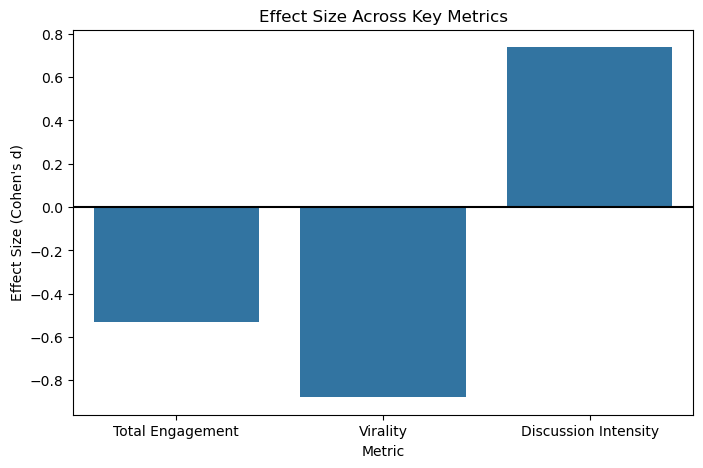

In [109]:
effects = pd.DataFrame({
    "Metric": ["Total Engagement", "Virality", "Discussion Intensity"],
    "Effect Size (Cohen's d)": [
        cohens_d(
            df[df["ab_group_basic"]=="Human_Content"]["total_engagement"],
            df[df["ab_group_basic"]=="AI_Like_Content"]["total_engagement"]
        ),
        cohens_d(
            df[df["ab_group_basic"]=="Human_Content"]["virality_score"],
            df[df["ab_group_basic"]=="AI_Like_Content"]["virality_score"]
        ),
        cohens_d(
            df[df["ab_group_basic"]=="Human_Content"]["discussion_intensity"],
            df[df["ab_group_basic"]=="AI_Like_Content"]["discussion_intensity"]
        )
    ]
})

plt.figure(figsize=(8,5))
sns.barplot(data=effects, x="Metric", y="Effect Size (Cohen's d)")
plt.axhline(0, color="black")
plt.title("Effect Size Across Key Metrics")
plt.show()


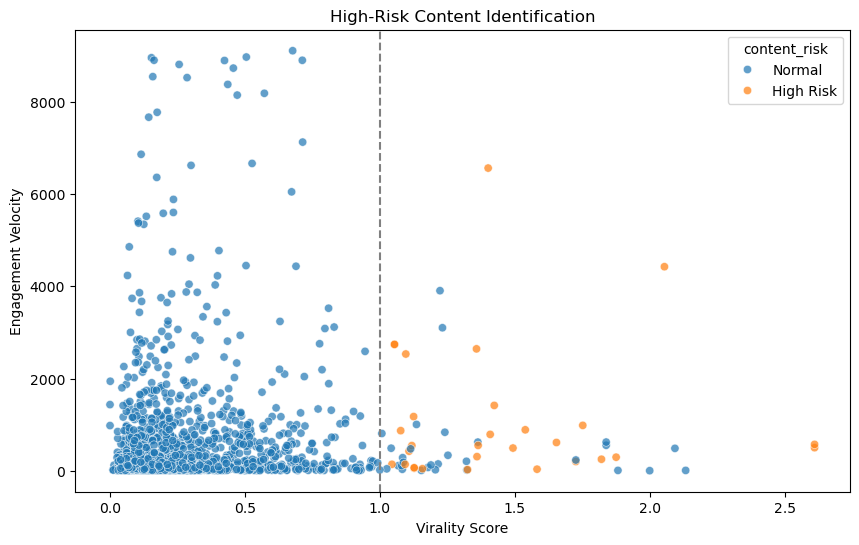

In [111]:
plt.figure(figsize=(10,6))
sns.scatterplot(
    data=df,
    x="virality_score",
    y="engagement_velocity",
    hue="content_risk",
    alpha=0.7
)
plt.axvline(1, linestyle="--", color="grey")
plt.title("High-Risk Content Identification")
plt.xlabel("Virality Score")
plt.ylabel("Engagement Velocity")
plt.show()


In [112]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(
    style="whitegrid",
    palette="Set2",   # clean & colorful
    font_scale=1.1
)

plt.rcParams["figure.figsize"] = (10,6)


In [113]:
AB_COLORS = {
    "Human_Content": "#2ECC71",   # green (trust)
    "AI_Like_Content": "#E74C3C"  # red (risk)
}


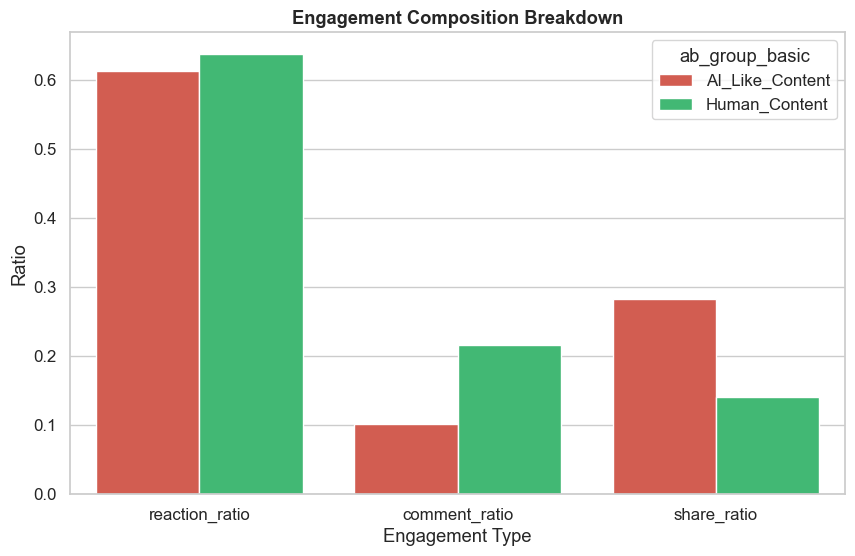

In [115]:
palette_engagement = {
    "reaction_ratio": "#3498DB",
    "comment_ratio": "#9B59B6",
    "share_ratio": "#F1C40F"
}

sns.barplot(
    data=composition_melted,
    x="Engagement Type",
    y="Ratio",
    hue="ab_group_basic",
    palette=AB_COLORS
)

plt.title("Engagement Composition Breakdown", weight="bold")
plt.show()
